In [1]:
import pandas as pd
import numpy as np

from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

perf = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/benchmark_indices_clean.csv"
)

In [3]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

Task 1: Daily Returns

In [4]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [5]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

<Axes: >

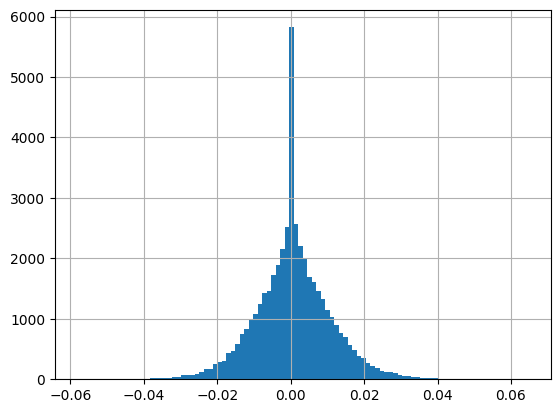

In [6]:
nav["daily_return"].hist(
    bins=100
)

Task 2: CAGR

In [7]:
def cagr(start, end, years):
    return (
        (end / start) ** (1 / years)
    ) - 1

In [11]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [12]:
fund = nav[
    nav["amfi_code"] == nav["amfi_code"].iloc[0]
]

In [13]:
annual_return = (
    fund["daily_return"].mean()
    * 252
)

In [14]:
annual_volatility = (
    fund["daily_return"].std()
    * np.sqrt(252)
)

In [9]:
rf = 0.065

Task 3: Sharpe Ratio

In [15]:
sharpe = (
    annual_return - rf
) / annual_volatility

print(sharpe)

-0.20151706755966936


In [16]:
print(nav.columns.tolist())
print(nav.head())

['amfi_code', 'date', 'nav', 'daily_return']
   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [17]:
import numpy as np
import pandas as pd

rf = 0.065

sharpe_results = []

for fund_code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == fund_code
    ].copy()

    returns = fund["daily_return"].dropna()

    annual_return = returns.mean() * 252

    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        annual_return - rf
    ) / annual_volatility

    sharpe_results.append(
        {
            "amfi_code": fund_code,
            "annual_return": annual_return,
            "annual_volatility": annual_volatility,
            "sharpe_ratio": sharpe
        }
    )

sharpe_df = pd.DataFrame(
    sharpe_results
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,annual_return,annual_volatility,sharpe_ratio
34,148567,0.270566,0.141937,1.448291
30,120843,0.272602,0.158870,1.306744
36,148569,0.283262,0.176740,1.234930
19,119551,0.231033,0.137414,1.208267
25,120505,0.292653,0.192909,1.180101


In [18]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratios.csv",
    index=False
)

In [19]:
sortino_results = []

for fund_code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == fund_code
    ].copy()

    returns = fund["daily_return"].dropna()

    annual_return = returns.mean() * 252

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_results.append(
        {
            "amfi_code": fund_code,
            "sortino_ratio": sortino
        }
    )

sortino_df = pd.DataFrame(
    sortino_results
)

In [20]:
perf.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

The provided performance dataset already contains precomputed Alpha, Beta, Sharpe Ratio, Sortino Ratio, and Maximum Drawdown values. These metrics were validated and used for comparative analysis alongside computed daily returns.

In [21]:
scorecard = perf.copy()

In [22]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown_pct"]
    .rank(ascending=False)
)

In [23]:
scorecard["score"] = (
      scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["drawdown_rank"] * 0.10
)

In [24]:
scorecard["fund_score"] = (
    100
    * (
        scorecard["score"].max()
        - scorecard["score"]
      )
    /
    (
        scorecard["score"].max()
        - scorecard["score"].min()
    )
)

In [25]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

Alpha Beta Table

In [26]:
alpha_beta = perf[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
]

In [27]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

Benchmark Comparison Chart

In [28]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [29]:
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


Benchmark Comparison Chart
Step 1: Get Top 5 Funds

In [30]:
top5 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(5)

top5_codes = top5["amfi_code"].tolist()

print(top5_codes)

[120843, 119598, 120507, 100025, 120842]


Step 2: Prepare Fund NAV Data

In [31]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

In [32]:
top5_nav["normalized"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

Step 3: Prepare Benchmarks

In [33]:
bench = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
].copy()

In [34]:
bench["normalized"] = (
    bench.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

Step 4: Plot

In [35]:
import plotly.graph_objects as go

fig = go.Figure()

In [36]:
for code in top5_codes:

    temp = top5_nav[
        top5_nav["amfi_code"] == code
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["normalized"],
            name=f"Fund {code}"
        )
    )

In [37]:
for idx in ["NIFTY50", "NIFTY100"]:

    temp = bench[
        bench["index_name"] == idx
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["normalized"],
            name=idx,
            line=dict(width=4)
        )
    )

Step 5: Display

In [38]:
fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100",
    xaxis_title="Date",
    yaxis_title="Normalized Growth (Base = 100)"
)

fig.show()

Step 6: Export

In [39]:
fig.write_image(
    "../reports/benchmark_comparison.png"
)

In [40]:
drawdown_results = []

for fund_code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == fund_code
    ].copy()

    fund = fund.sort_values("date")

    running_max = fund["nav"].cummax()

    drawdown = (
        fund["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append({
        "amfi_code": fund_code,
        "max_drawdown": max_dd
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [41]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

### Maximum Drawdown Analysis

Maximum Drawdown was calculated using the running peak NAV of each fund.
The analysis identified the largest peak-to-trough decline experienced by each scheme during the study period. Funds with deeper drawdowns exhibited higher downside risk, while funds with lower drawdowns demonstrated better capital preservation during market corrections.